**DATA ANALYSIS**

dalam tahap ini kami menggunakan 4 metode analisis yaitu descriptive analysis, analisis prediktif, Decision Tree, Logistic Regression

In [25]:
import pandas as pd
import os
import matplotlib.pyplot as plt

processed_path = "/content/drive/MyDrive/Tugas Big-Data/OULAD_EarlyWarning/data/processed/"

print("Isi folder processed:")
print(os.listdir(processed_path))

merged_data = pd.read_csv(processed_path + "merged_processed_oulad.csv")

print("\nUkuran merged_data:", merged_data.shape)
display(merged_data.head())
print("\nKolom:")
print(merged_data.columns.tolist())

Isi folder processed:
['merged_processed_oulad.csv']

Ukuran merged_data: (32593, 28)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,active_days,avg_score,max_score,total_assessments,total_submitted,assessment_completion_rate,module_presentation_length,risk_label,low_engagement,low_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,40.0,82.0,85.0,5.0,5.0,1.0,268,0,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,80.0,66.4,70.0,5.0,5.0,1.0,268,0,0,1
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,12.0,0.0,0.0,0.0,0.0,0.0,268,1,1,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,123.0,76.0,88.0,5.0,5.0,1.0,268,0,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,70.0,54.4,75.0,5.0,5.0,1.0,268,0,0,1



Kolom:
['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result', 'date_registration', 'date_unregistration', 'is_withdrawn', 'total_clicks', 'avg_clicks', 'last_interaction_day', 'active_days', 'avg_score', 'max_score', 'total_assessments', 'total_submitted', 'assessment_completion_rate', 'module_presentation_length', 'risk_label', 'low_engagement', 'low_score']


**1. ANALISIS DESKRIPTIF**

Metode ini dipakai untuk membaca pola data lebih dulu sebelum membuat model prediksi.

**Distribusi hasil akhir dari mahasiswa**

,final_result,jumlah_mahasiswa
0,Pass,12361
1,Withdrawn,10156
2,Fail,7052
3,Distinction,3024


,final_result,persentase
0,Pass,37.93
1,Withdrawn,31.16
2,Fail,21.64
3,Distinction,9.28


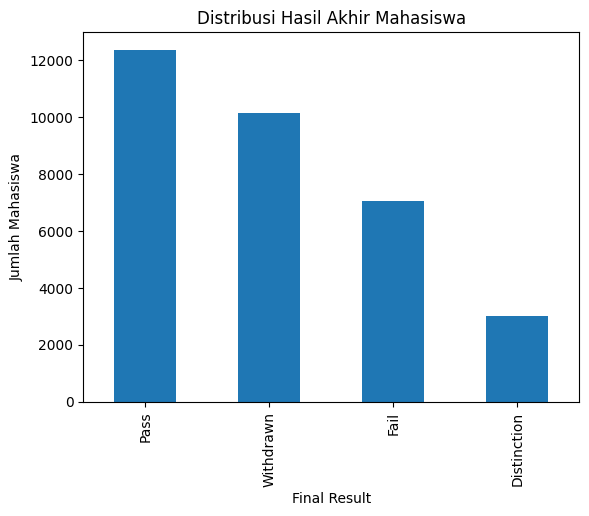

In [5]:
# Jumlah mahasiswa per final_result
final_result_count = merged_data["final_result"].value_counts().reset_index()
final_result_count.columns = ["final_result", "jumlah_mahasiswa"]
display(final_result_count)

# Persentase mahasiswa per final_result
final_result_pct = merged_data["final_result"].value_counts(normalize=True).reset_index()
final_result_pct.columns = ["final_result", "persentase"]
final_result_pct["persentase"] = (final_result_pct["persentase"] * 100).round(2)
display(final_result_pct)

# Visualisasi
merged_data["final_result"].value_counts().plot(kind="bar")
plt.title("Distribusi Hasil Akhir Mahasiswa")
plt.xlabel("Final Result")
plt.ylabel("Jumlah Mahasiswa")
plt.show()

**Distribusi hasil akhir per modul**

final_result,Distinction,Fail,Pass,Withdrawn
code_module,,,,
AAA,44,91,487,126
BBB,677,1767,3077,2388
CCC,498,781,1180,1975
DDD,383,1412,2227,2250
EEE,356,562,1294,722
FFF,670,1711,2978,2403
GGG,396,728,1118,292


final_result,Distinction,Fail,Pass,Withdrawn
code_module,,,,
AAA,5.88,12.17,65.11,16.84
BBB,8.56,22.34,38.91,30.19
CCC,11.23,17.61,26.61,44.54
DDD,6.11,22.51,35.51,35.87
EEE,12.13,19.15,44.10,24.61
FFF,8.63,22.04,38.37,30.96
GGG,15.63,28.73,44.12,11.52


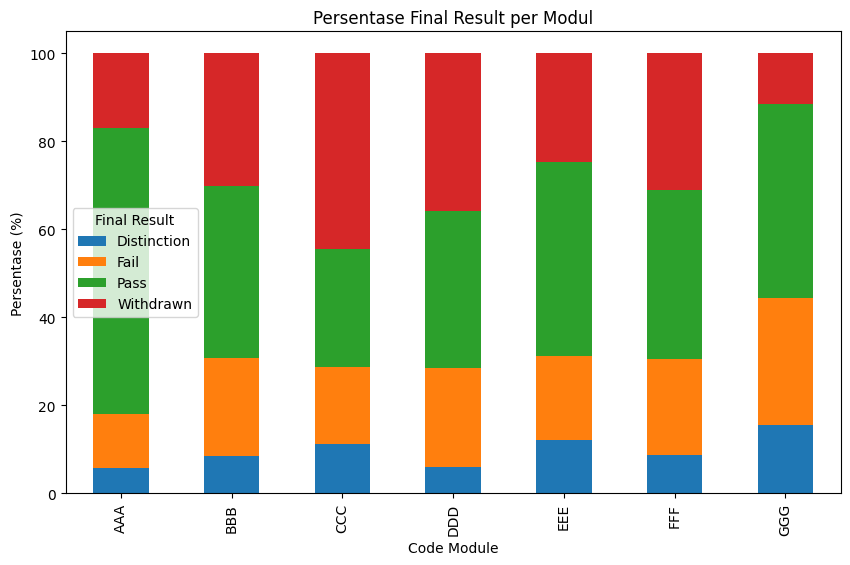

In [6]:
module_result = pd.crosstab(
    merged_data["code_module"],
    merged_data["final_result"]
)

display(module_result)

# persentase per modul
module_result_pct = pd.crosstab(
    merged_data["code_module"],
    merged_data["final_result"],
    normalize="index"
) * 100

display(module_result_pct.round(2))

# Visualisasi
module_result_pct.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Persentase Final Result per Modul")
plt.xlabel("Code Module")
plt.ylabel("Persentase (%)")
plt.legend(title="Final Result")
plt.show()

**Aktivitas VLE berdasarkan hasil akhir**

,total_clicks,avg_clicks,active_days,last_interaction_day
final_result,,,,
Distinction,2666.76,3.61,110.04,244.79
Fail,651.85,2.89,33.18,134.72
Pass,1921.81,3.49,87.04,242.03
Withdrawn,313.95,2.07,16.29,49.22


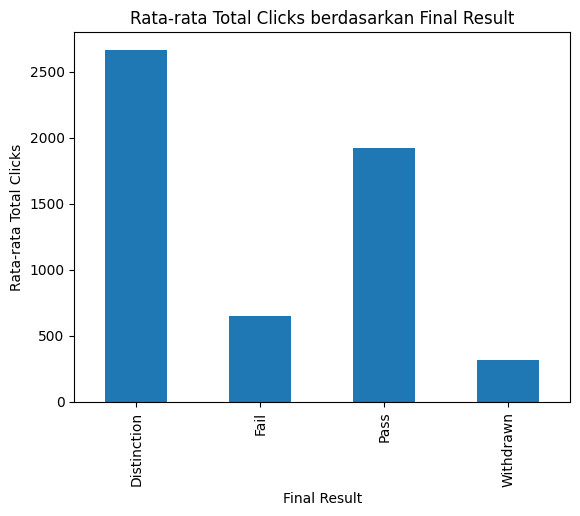

In [7]:
vle_summary = merged_data.groupby("final_result")[
    ["total_clicks", "avg_clicks", "active_days", "last_interaction_day"]
].mean().round(2)

display(vle_summary)

# Visualisasi total Clicks
merged_data.groupby("final_result")["total_clicks"].mean().plot(kind="bar")
plt.title("Rata-rata Total Clicks berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Total Clicks")
plt.show()

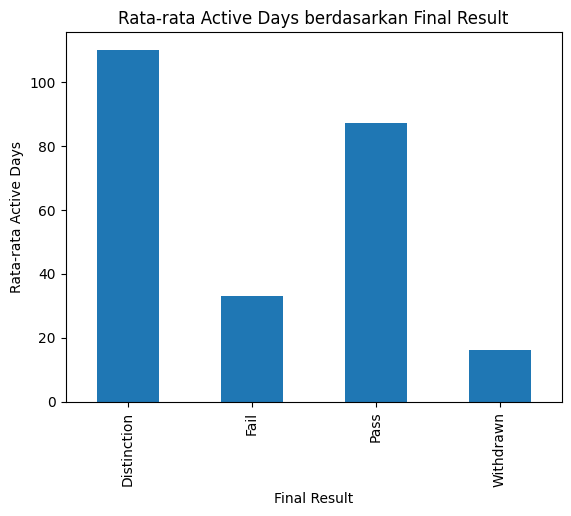

In [8]:
#Visualisasi active days
merged_data.groupby("final_result")["active_days"].mean().plot(kind="bar")
plt.title("Rata-rata Active Days berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Active Days")
plt.show()

**Performa asesmen berdasarkan hasil akhir**

In [10]:
assessment_summary = merged_data.groupby("final_result")[
    ["avg_score", "max_score", "assessment_completion_rate"]
].mean().round(2)

display(assessment_summary)

,avg_score,max_score,assessment_completion_rate
final_result,,,
Distinction,88.49,97.98,1.00
Fail,52.41,64.65,0.79
Pass,76.13,92.29,0.99
Withdrawn,29.41,33.64,0.45


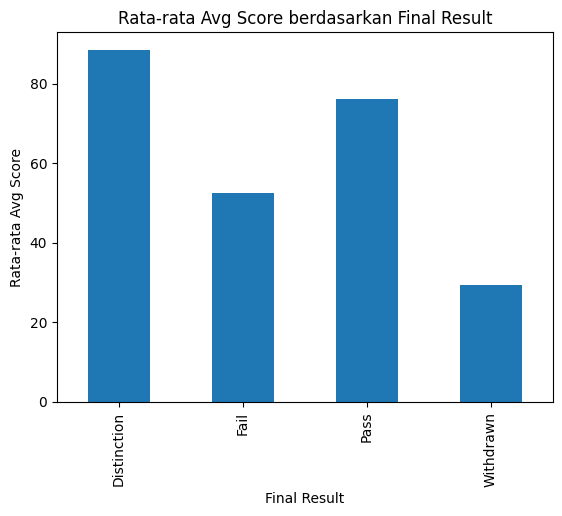

In [11]:
# Visualisasi Avg_score
merged_data.groupby("final_result")["avg_score"].mean().plot(kind="bar")
plt.title("Rata-rata Avg Score berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Avg Score")
plt.show()

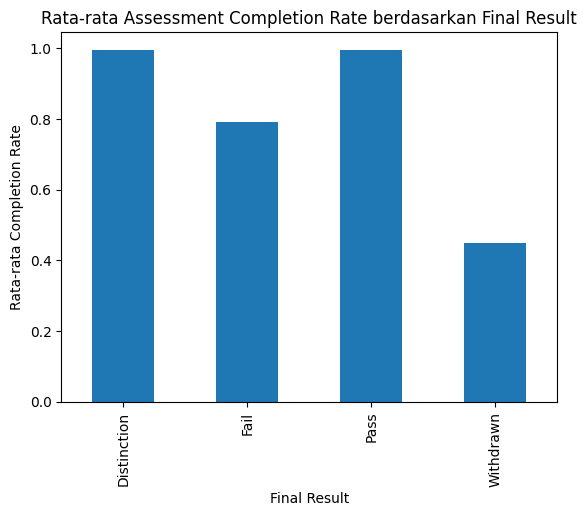

In [12]:
# Visualiasai assessment completion rate
merged_data.groupby("final_result")["assessment_completion_rate"].mean().plot(kind="bar")
plt.title("Rata-rata Assessment Completion Rate berdasarkan Final Result")
plt.xlabel("Final Result")
plt.ylabel("Rata-rata Completion Rate")
plt.show()

**Distribusi low_engagement terhadap final_result**

In [13]:
low_engagement_result = pd.crosstab(
    merged_data["low_engagement"],
    merged_data["final_result"],
    normalize="index"
) * 100

display(low_engagement_result.round(2))

final_result,Distinction,Fail,Pass,Withdrawn
low_engagement,,,,
0,16.23,13.97,59.81,9.99
1,2.32,29.31,16.02,52.35


**Distribusi low_score terhadap final_result**

In [16]:
low_score_result = pd.crosstab(
    merged_data["low_score"],
    merged_data["final_result"],
    normalize="index"
) * 100

display(low_score_result.round(2))

final_result,Distinction,Fail,Pass,Withdrawn
low_score,,,,
0,17.97,13.39,56.05,12.59
1,0.55,29.92,19.74,49.79


**Distribusi risk_label**

In [15]:
risk_label_count = merged_data["risk_label"].value_counts().reset_index()
risk_label_count.columns = ["risk_label", "jumlah_mahasiswa"]
display(risk_label_count)

,risk_label,jumlah_mahasiswa
0,1,17208
1,0,15385


**2. ANALISIS PREDIKTIF**

Metode ini dipakai untuk membuat model yang bisa memprediksi mahasiswa berisiko gagal atau withdrawal lebih awal

**PERSIAPAN DATA**

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score

# pilih fitur
feature_cols = [
    "total_clicks", "avg_clicks", "active_days", "last_interaction_day",
    "avg_score", "max_score", "total_assessments", "total_submitted",
    "assessment_completion_rate", "num_of_prev_attempts",
    "studied_credits", "code_module", "highest_education",
    "age_band", "imd_band", "disability", "gender"
]

X = merged_data[feature_cols].copy()
y = merged_data["risk_label"].copy()

print("Ukuran X:", X.shape)
print("Ukuran y:", y.shape)

Ukuran X: (32593, 17)
Ukuran y: (32593,)


In [37]:
# Encoding fitur kategorikal
X = pd.get_dummies(X, drop_first=True)

print("Ukuran X setelah encoding:", X.shape)
display(X.head())

Ukuran X setelah encoding: (32593, 35)


,total_clicks,avg_clicks,active_days,last_interaction_day,avg_score,max_score,total_assessments,total_submitted,assessment_completion_rate,num_of_prev_attempts,...,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,disability_Y,gender_M
0,934.0,4.765306,40.0,253.0,82.0,85.0,5.0,5.0,1.0,0,...,False,False,False,False,False,False,True,False,False,True
1,1435.0,3.337209,80.0,239.0,66.4,70.0,5.0,5.0,1.0,0,...,False,False,False,False,False,False,False,False,False,False
2,281.0,3.697368,12.0,12.0,0.0,0.0,0.0,0.0,0.0,0,...,True,False,False,False,False,False,False,False,True,False
3,2158.0,3.254902,123.0,264.0,76.0,88.0,5.0,5.0,1.0,0,...,False,False,True,False,False,False,False,False,False,False
4,1034.0,2.937500,70.0,247.0,54.4,75.0,5.0,5.0,1.0,0,...,False,False,True,False,False,False,False,False,False,False


In [38]:
#membagi data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (26074, 35)
X_test : (6519, 35)
y_train: (26074,)
y_test : (6519,)


**MODEL Decision Tree sebagai model Utama**


In [39]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Accuracy Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Accuracy Decision Tree: 0.930357416781715

Confusion Matrix:
[[2975  102]
 [ 352 3090]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      3077
           1       0.97      0.90      0.93      3442

    accuracy                           0.93      6519
   macro avg       0.93      0.93      0.93      6519
weighted avg       0.93      0.93      0.93      6519



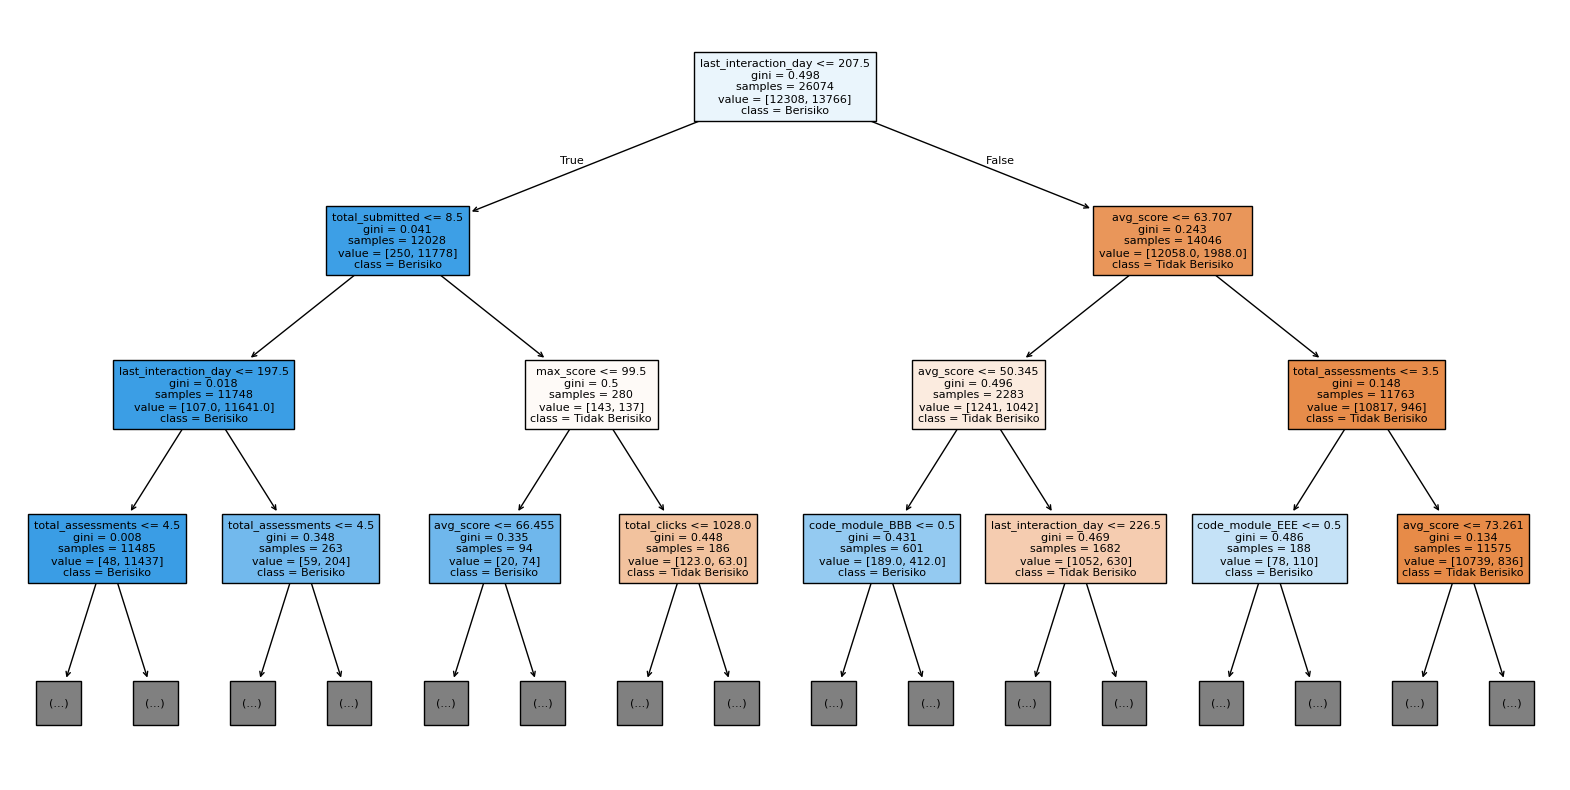

In [40]:
# visualisasi
plt.figure(figsize=(20,10))
plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=["Tidak Berisiko", "Berisiko"],
    max_depth=3,
    fontsize=8
)
plt.show()

In [41]:
# Feature Importance Decision Tree
dt_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": dt_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(dt_importance.head(10))

,feature,importance
3,last_interaction_day,0.887180
4,avg_score,0.070373
7,total_submitted,0.015474
6,total_assessments,0.010920
14,code_module_EEE,0.003585
11,code_module_BBB,0.003380
15,code_module_FFF,0.002661
0,total_clicks,0.002451
5,max_score,0.002421
2,active_days,0.001491


**MODEL Logistic Regression sebagai model Pembanding**

In [42]:
# menggunakan StandardScaler karena sensitif terhadap skala data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("Accuracy Logistic Regression:", accuracy_score(y_test, y_pred_log))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy Logistic Regression: 0.9271360638134684

Confusion Matrix:
[[2969  108]
 [ 367 3075]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      3077
           1       0.97      0.89      0.93      3442

    accuracy                           0.93      6519
   macro avg       0.93      0.93      0.93      6519
weighted avg       0.93      0.93      0.93      6519



# Perbandingan 2 model

In [44]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_log)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_log)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_log)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_log)
    ]
})

display(comparison.sort_values(by="F1-Score", ascending=False))

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.930357,0.968045,0.897734,0.931565
1,Logistic Regression,0.927136,0.966070,0.893376,0.928302


**SIMPAN OUTPUT**

In [46]:
base_path = "/content/drive/MyDrive/Tugas Big-Data/OULAD_EarlyWarning/"
output_path = os.path.join(base_path, "data/output/")
os.makedirs(output_path, exist_ok=True)

# 1. Simpan tabel perbandingan model
comparison.to_csv(output_path + "model_comparison.csv", index=False)

# 2. Simpan feature importance Decision Tree
dt_importance.to_csv(output_path + "feature_importance_dt.csv", index=False)

# 3. Simpan hasil prediksi
test_index = X_test.index

prediction_result = merged_data.loc[test_index, [
    "id_student", "code_module", "code_presentation",
    "final_result", "risk_label",
    "total_clicks", "avg_score", "assessment_completion_rate"
]].copy()

prediction_result["predicted_dt"] = y_pred_dt
prediction_result["predicted_logreg"] = y_pred_log

prediction_result.to_csv(output_path + "prediction_result.csv", index=False)

# 4. Simpan daftar mahasiswa berisiko
at_risk_students = merged_data[merged_data["risk_label"] == 1].copy()
at_risk_students.to_csv(output_path + "at_risk_students.csv", index=False)

print("File output berhasil disimpan")
print(os.listdir(output_path))

File output berhasil disimpan
['model_comparison.csv', 'feature_importance_dt.csv', 'prediction_result.csv', 'at_risk_students.csv']
